<h1>Smart MCQ Solver Challenge</h1>

<h2>About the Competition</h2>
<p>
The Smart MCQ Solver Challenge aims to develop intelligent AI and machine learning systems capable of solving complex multiple-choice questions. Each question consists of a prompt and five answer options labeled A, B, C, D, and E. Participants must predict the top three most likely correct answers in ranked order.
</p>

<h2>Objective</h2>
<p>
The goal of this competition is to build models that can understand context, perform reasoning, and effectively rank answer choices. Participants are encouraged to explore transformer-based architectures, retrieval-augmented generation (RAG), fine-tuned language models, ensemble methods, and efficient inference techniques to maximize performance.
</p>

<h2>Dataset Description</h2>

<table border="1" cellpadding="8" cellspacing="0">
    <thead>
        <tr>
            <th>Column</th>
            <th>Data Type</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>id</td>
            <td>int64</td>
            <td>Unique identifier for each question.</td>
        </tr>
        <tr>
            <td>prompt</td>
            <td>object</td>
            <td>The multiple-choice question or prompt.</td>
        </tr>
        <tr>
            <td>A</td>
            <td>object</td>
            <td>Answer option A.</td>
        </tr>
        <tr>
            <td>B</td>
            <td>object</td>
            <td>Answer option B.</td>
        </tr>
        <tr>
            <td>C</td>
            <td>object</td>
            <td>Answer option C.</td>
        </tr>
        <tr>
            <td>D</td>
            <td>object</td>
            <td>Answer option D.</td>
        </tr>
        <tr>
            <td>E</td>
            <td>object</td>
            <td>Answer option E.</td>
        </tr>
        <tr>
            <td>answer</td>
            <td>object</td>
            <td>Correct answer label (A, B, C, D, or E).</td>
        </tr>
    </tbody>
</table>

In [123]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')


## Dataset Loading & Exploration

In [4]:
train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print('Loaded')

Loaded


In [126]:
train_df.head(3)

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


In [127]:
test_df.head(3)

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...


In [128]:
print(f"Train Dataset Shape: {train_df.shape} | Test Dataset Shape: {test_df.shape}")

Train Dataset Shape: (2000, 8) | Test Dataset Shape: (500, 7)


In [129]:
print(f"Train_df Columns: {train_df.columns.to_list()}")
print(" ")
print(f"Test_df Columns: {test_df.columns.to_list()}")

Train_df Columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
 
Test_df Columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']


In [130]:
train_df.isna().sum()
# print('No NaN Values Present in Any Col')

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [131]:
test_df.isna().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

In [132]:
print(train_df['id'].duplicated().sum())
print(" ")
print(test_df['id'].duplicated().sum())

0
 
0


In [133]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [134]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


## Data Preprocessing & EDA

/tmp/ipykernel_58/1979750737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df["answer"],palette='Set2')


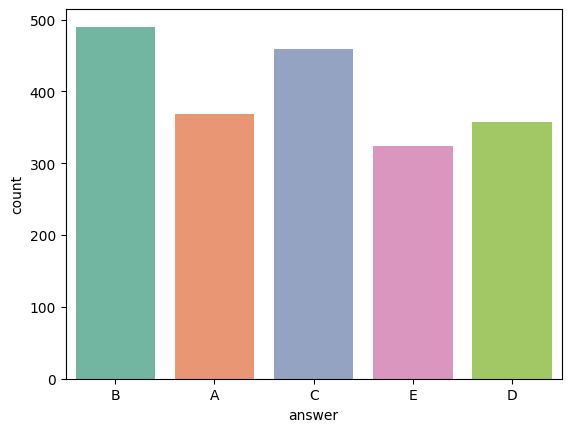

In [137]:
#eda
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=train_df["answer"],palette='Set2')
plt.show()

In [8]:
train_df["prompt_len"] = train_df["prompt"].apply(len)
train_df["prompt_len"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_len, dtype: float64

<Axes: xlabel='prompt_len', ylabel='Count'>

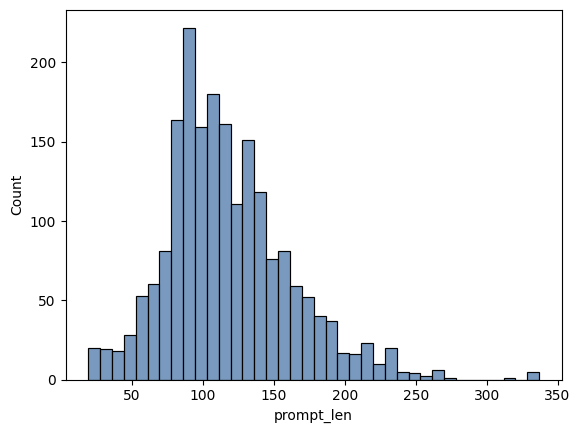

In [13]:
sns.histplot(train_df["prompt_len"],color='#4C78A8')

In [140]:
from wordcloud import WordCloud

In [141]:
train_df['prompt_len'] = train_df['prompt'].str.len()
test_df['prompt_len']  = test_df['prompt'].str.len()


In [142]:
for col in ['A','B','C','D','E']:
    train_df[f'{col}_len'] = train_df[col].str.len()
    test_df[f'{col}_len']  = test_df[col].str.len()


In [143]:
len_cols = ['A_len','B_len','C_len','D_len','E_len']
train_df['avg_option_len'] = train_df[len_cols].mean(axis=1)
test_df['avg_option_len']  = test_df[len_cols].mean(axis=1)


In [144]:
train_df['max_option_len'] = train_df[len_cols].max(axis=1)
test_df['max_option_len']  = test_df[len_cols].max(axis=1)


In [145]:
train_df['min_option_len'] = train_df[len_cols].min(axis=1)
test_df['min_option_len']  = test_df[len_cols].min(axis=1)


In [146]:
train_df['option_len_range'] = train_df['max_option_len'] - train_df['min_option_len']
test_df['option_len_range']  = test_df['max_option_len'] - test_df['min_option_len']


In [147]:
train_df['prompt_word_count'] = train_df['prompt'].str.split().str.len()
test_df['prompt_word_count']  = test_df['prompt'].str.split().str.len()


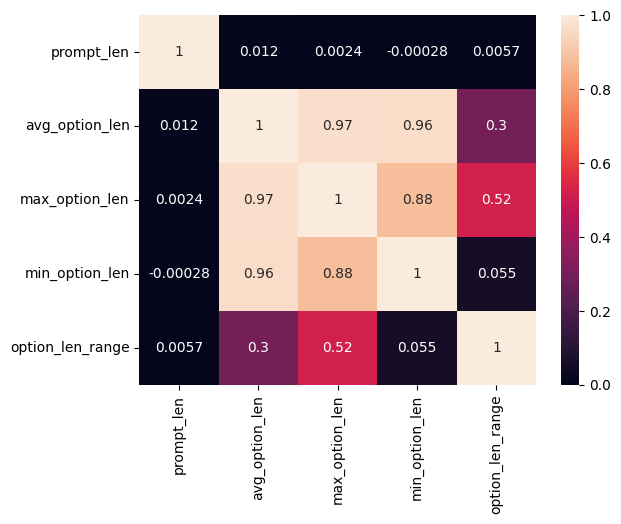

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    "prompt_len",
    "avg_option_len",
    "max_option_len",
    "min_option_len",
    "option_len_range"
]

sns.heatmap(
    train_df[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

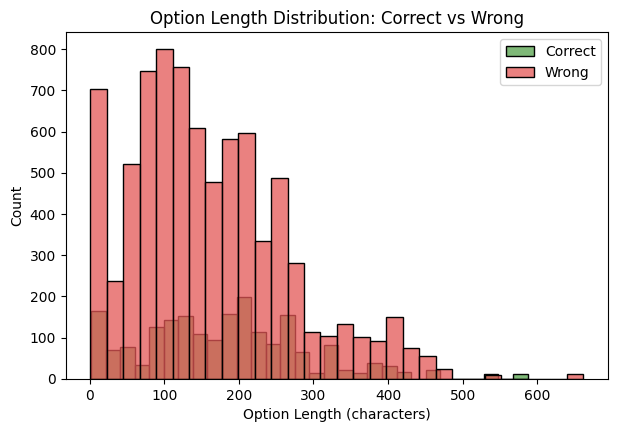

In [15]:
option_cols = ['A', 'B', 'C', 'D', 'E']
correct_lengths = []
wrong_lengths = []

for _, row in train_df.iterrows():
    lengths = {c: len(str(row[c])) for c in option_cols}
    for c in option_cols:
        if c == row['answer']:
            correct_lengths.append(lengths[c])
        else:
            wrong_lengths.append(lengths[c])

plt.figure(figsize=(7, 4.5))
sns.histplot(correct_lengths, bins=30, color='#54A24B',label='Correct', edgecolor='black')
sns.histplot(wrong_lengths, bins=30, color='#E45756',label='Wrong', edgecolor='black')
plt.title('Option Length Distribution: Correct vs Wrong')
plt.xlabel('Option Length (characters)')
plt.ylabel('Count')
plt.legend()
plt.show()

## Feature Engineering

Pairwise rows: each question-option pair gets its own row for ranking.

In [ ]:
OPTION_COLS = ['A', 'B', 'C', 'D', 'E']

In [ ]:
def get_option_tail(row):
    opts = [str(row[c]) for c in OPTION_COLS]
    min_len = min(len(o) for o in opts)
    div = 0
    for i in range(min_len):
        if len(set(o[i] for o in opts)) > 1:
            div = i
            break
    return {c: o[div:] for c, o in zip(OPTION_COLS, opts)}, div


def make_pairwise(df, is_train=True):
    rows = []
    for _, r in df.iterrows():
        tails, div  = get_option_tail(r)
        p_words     = set(re.findall(r'\b\w{4,}\b', str(r['prompt']).lower()))
        opt_lens    = [len(str(r[c])) for c in OPTION_COLS]
        avg_len     = np.mean(opt_lens) + 1e-6
        all_words   = set()
        for c in OPTION_COLS:
            all_words |= set(re.findall(r'\b\w{4,}\b', str(r[c]).lower()))
        for j, c in enumerate(OPTION_COLS):
            o_words = set(re.findall(r'\b\w{4,}\b', str(r[c]).lower()))
            t_words = set(re.findall(r'\b\w{4,}\b', tails[c].lower()))
            rows.append({
                'text_full':      str(r['prompt']) + ' [ANS] ' + str(r[c]),
                'text_tail':      tails[c],
                'qid':            r['id'],
                'option':         c,
                'rel_len':        opt_lens[j] / avg_len,
                'overlap':        len(p_words & o_words) / max(len(p_words), 1),
                'tail_overlap':   len(p_words & t_words) / max(len(p_words), 1),
                'unique_ratio':   len(o_words - (all_words - o_words)) / max(len(o_words), 1),
                'div_point':      div,
                'tail_len_ratio': len(tails[c]) / max(len(str(r[c])), 1),
                'label':          1 if (is_train and r.get('answer') == c) else 0
            })
    return pd.DataFrame(rows)


In [ ]:
print('Building pairwise train...')
pw_train = make_pairwise(train_df, is_train=True)
print('Done:', pw_train.shape)

In [ ]:
print('Building pairwise test...')
pw_test = make_pairwise(test_df, is_train=False)
print('Done:', pw_test.shape)

In [ ]:
pw_train.head(6)


## TF-IDF Vectorization

Two TF-IDF matrices: word n-grams on full text, char n-grams on tail (the differentiating suffix). Char n-grams catch subtle single-word differences like light-ion vs heavy-ion.

In [ ]:
tfidf_word = TfidfVectorizer(
    max_features=60000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
    analyzer='word'
)

tfidf_char = TfidfVectorizer(
    max_features=40000,
    ngram_range=(2, 5),
    sublinear_tf=True,
    min_df=1,
    analyzer='char_wb'
)


In [ ]:
Xw_tr  = tfidf_word.fit_transform(pw_train['text_full'])
Xw_tst = tfidf_word.transform(pw_test['text_full'])

Xc_tr  = tfidf_char.fit_transform(pw_train['text_tail'])
Xc_tst = tfidf_char.transform(pw_test['text_tail'])

print('Word TF-IDF train:', Xw_tr.shape)
print('Char TF-IDF train:', Xc_tr.shape)


In [ ]:
num_feats = ['rel_len', 'overlap', 'tail_overlap', 'unique_ratio', 'div_point', 'tail_len_ratio']

X_num_tr  = csr_matrix(pw_train[num_feats].values.astype(float))
X_num_tst = csr_matrix(pw_test[num_feats].values.astype(float))

X_tr  = hstack([Xw_tr, Xc_tr, X_num_tr])
X_tst = hstack([Xw_tst, Xc_tst, X_num_tst])
y_tr  = pw_train['label'].values

print('Full train matrix:', X_tr.shape)
print('Positive labels:', y_tr.sum(), '/', len(y_tr))


## MAP@3 Metric

In [ ]:
def apk(actual, predicted, k=3):
    score, hits = 0.0, 0
    for i, p in enumerate(predicted[:k]):
        if p == actual:
            hits += 1
            score += hits / (i + 1.0)
    return score


def mapk(actuals, preds, k=3):
    return float(np.mean([apk(a, p, k) for a, p in zip(actuals, preds)]))


def rank_preds(pw, scores, orig_df):
    pw = pw.copy()
    pw['score'] = scores
    preds = []
    for qid in orig_df['id']:
        q = pw[pw['qid'] == qid].sort_values('score', ascending=False)
        preds.append(q['option'].tolist()[:3])
    return preds


In [ ]:
print('MAP@3 check:', apk('A', ['A', 'B', 'C']))

## Model 1 - Logistic Regression

In [ ]:
groups = pw_train['qid'].values
gkf = GroupKFold(n_splits=5)

In [ ]:
oof_lr = np.zeros(len(pw_train))
tst_lr = np.zeros(len(pw_test))

for fold, (ti, vi) in enumerate(gkf.split(X_tr, y_tr, groups)):
    lr = LogisticRegression(max_iter=2000, C=8.0, n_jobs=-1)
    lr.fit(X_tr[ti], y_tr[ti])
    oof_lr[vi] = lr.predict_proba(X_tr[vi])[:, 1]
    tst_lr    += lr.predict_proba(X_tst)[:, 1] / 5
    val_acc = accuracy_score(y_tr[vi], (oof_lr[vi] > 0.5).astype(int))
    print(f'Fold {fold + 1}  val_acc={val_acc:.4f}')


In [ ]:
lr_map3 = mapk(train_df['answer'].tolist(), rank_preds(pw_train, oof_lr, train_df))
print(f'LR OOF MAP@3: {lr_map3:.4f}')


## Model 2 - LightGBM

In [ ]:
oof_lgbm = np.zeros(len(pw_train))
tst_lgbm = np.zeros(len(pw_test))

for fold, (ti, vi) in enumerate(gkf.split(X_tr, y_tr, groups)):
    lgbm = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    )
    lgbm.fit(X_tr[ti], y_tr[ti])
    oof_lgbm[vi] = lgbm.predict_proba(X_tr[vi])[:, 1]
    tst_lgbm    += lgbm.predict_proba(X_tst)[:, 1] / 5
    val_acc = accuracy_score(y_tr[vi], (oof_lgbm[vi] > 0.5).astype(int))
    print(f'Fold {fold + 1}  val_acc={val_acc:.4f}')


In [ ]:
lgbm_map3 = mapk(train_df['answer'].tolist(), rank_preds(pw_train, oof_lgbm, train_df))
print(f'LGBM OOF MAP@3: {lgbm_map3:.4f}')


## Ensemble

In [ ]:
best_score, best_w = 0.0, 0.5

for w in np.arange(0.2, 0.85, 0.05):
    ens_oof = w * oof_lr + (1 - w) * oof_lgbm
    s = mapk(train_df['answer'].tolist(), rank_preds(pw_train, ens_oof, train_df))
    print(f'w_lr={w:.2f}  MAP@3={s:.4f}')
    if s > best_score:
        best_score, best_w = s, w

print()
print(f'Best LR weight: {best_w:.2f}')
print(f'LR alone:   {lr_map3:.4f}')
print(f'LGBM alone: {lgbm_map3:.4f}')
print(f'Ensemble:   {best_score:.4f}')


## Submission

In [ ]:
ens_tst = best_w * tst_lr + (1 - best_w) * tst_lgbm
test_top3 = rank_preds(pw_test, ens_tst, test_df)

submission = pd.DataFrame({
    'ID': test_df['id'],
    'Prediction': [' '.join(p) for p in test_top3]
})

submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')


In [ ]:
submission.head(10)

In [ ]:
assert len(submission) == len(test_df)
assert submission['Prediction'].str.match(r'^[A-E] [A-E] [A-E]$').all()
print('Format OK')
